In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
data=pd.read_csv("person.csv")
data

,Name,Age,Gender,Salary,City
0,Ali,22.0,Male,25000.0,Jaipur
1,Ali,22.0,Male,25000.0,Jaipur
2,Sara,25.0,Female,30000.0,Delhi
3,John,NaN,Male,35000.0,Mumbai
4,Ali,22.0,Male,25000.0,Jaipur
5,Emma,150.0,Female,NaN,Delhi
6,Emma,150.0,Female,NaN,Delhi
7,Tom,28.0,Male,45000.0,NaN
8,Tom,28.0,Male,45000.0,NaN
9,Anna,24.0,Female,32000.0,Jaipur


In [3]:
# Outliers
# step 1: Calculate Q1 and Q3
Q1 = data["Age"].quantile(0.25)
Q3 = data["Age"].quantile(0.75)
print("Q1 =", Q1)
print("Q3 =", Q3)

Q1 = 24.0
Q3 = 30.0


In [4]:
# step 2: Calculate IQR
IQR=Q3-Q1
IQR

np.float64(6.0)

In [5]:
# step 3: Calculate Lower and Upper Limits
lower_limit = Q1-1.5 * IQR
lower_limit

np.float64(15.0)

In [6]:
upper_limit = Q3 + 1.5 * IQR
upper_limit

np.float64(39.0)

In [8]:
# detect outliers
age_outliers = data[
    (data["Age"]< lower_limit) | (data["Age"]> upper_limit)
]
age_outliers

,Name,Age,Gender,Salary,City
5,Emma,150.0,Female,NaN,Delhi
6,Emma,150.0,Female,NaN,Delhi
10,David,-5.0,Male,28000.0,Mumbai
24,Vikas,120.0,Male,250000.0,Jaipur


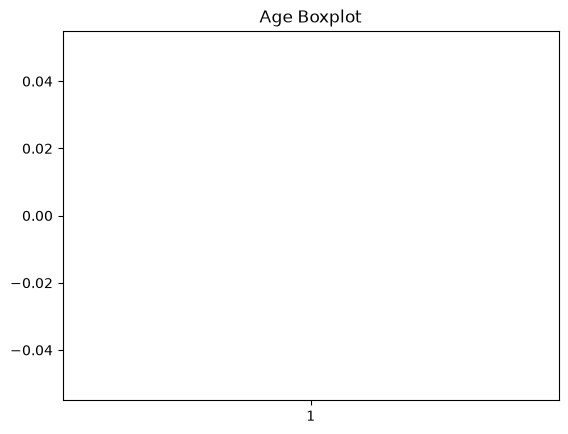

In [21]:
# Visualize Outliers Using Boxplot
## Age
import matplotlib.pyplot as plt
plt.boxplot(data["Age"])
plt.title("Age Boxplot")
plt.show()

In [12]:
data.groupby("Gender")["Salary"].mean()


Gender
Female    40800.000000
Male      56071.428571
Name: Salary, dtype: float64

In [14]:
data.groupby("City")["Salary"].mean()


City
Delhi     48285.714286
Jaipur    58555.555556
Mumbai    39666.666667
Name: Salary, dtype: float64

In [17]:
data.groupby("City")["Name"].count()


City
Delhi     9
Jaipur    9
Mumbai    6
Name: Name, dtype: int64

In [19]:
data["Gender"].value_counts()

Gender
Male      14
Female    12
Name: count, dtype: int64

In [20]:
data["City"].value_counts()

City
Jaipur    9
Delhi     9
Mumbai    6
Name: count, dtype: int64